# Preprocessing
This notebook will be used for preprocessing steps.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

In [2]:
# ── Data path ────────────────────────────────────────────────────
# CSVs are stored locally and gitignored. See data-loading-guide.md.
DATA_DIR = Path.home()  # adjust if moved

FILE_MONTHS = [
    'CRMLSSold202511.csv',   # November 2025
    'CRMLSSold202512.csv',   # December 2025
    'CRMLSSold202601.csv',   # January 2026
    'CRMLSSold202602.csv',   # February 2026
    'CRMLSSold202603.csv',   # March 2026
    'CRMLSSold202604.csv',   # April 2026
    'CRMLSSold202605.csv',   # May 2026  <- held-out test month
]

frames = []
for fname in FILE_MONTHS:
    df_month = pd.read_csv(DATA_DIR / fname, low_memory=False)
    df_month['_source_file'] = fname
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)
print(f'Total rows loaded (all PropertyTypes): {len(raw):,}')

Total rows loaded (all PropertyTypes): 143,492


In [3]:
# ── Apply project filter ─────────────────────────────────────────
df = raw[
    (raw['PropertyType'] == 'Residential') &
    (raw['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f'Rows after SFR filter: {len(df):,}')

# Parse dates
for col in ['CloseDate', 'ListingContractDate', 'PurchaseContractDate']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['CloseYearMonth'] = df['CloseDate'].dt.to_period('M')
df['CloseMonth']     = df['CloseDate'].dt.month

Rows after SFR filter: 71,466


---
## 1. Drop Fully-Null & Unusable Fields

Per the Week 2 field audit, these Trestle fields are 100% null in this CRMLS extract, or are
otherwise unusable (freeform text, redundant, or too sparse to impute reliably). They are
dropped before any further processing.

In [4]:
# Fields confirmed 100% null in this extract (Week 2 audit)
FULLY_NULL_FIELDS = [
    'AboveGradeFinishedArea',
    'BelowGradeFinishedArea',
    'BuildingAreaTotal',
    'TaxAnnualAmount',
    'CoveredSpaces',
    'FireplacesTotal',          # use FireplaceYN instead
    'BusinessType',             # not applicable to SFR
    'ElementarySchoolDistrict',
    'MiddleOrJuniorSchoolDistrict',
]

# Additional fields dropped for sparsity / redundancy (not 100% null, but unusable)
SPARSE_OR_REDUNDANT_FIELDS = [
    'WaterfrontYN',             # 99.9% null
    'BasementYN',               # 97.6% null
    'ElementarySchool',         # 87.3% null
    'MiddleOrJuniorSchool',     # 87.2% null
    'HighSchool',               # 83.2% null -- HighSchoolDistrict preferred
    'LotSizeAcres',             # redundant with LotSizeSquareFeet
    'LotSizeArea',              # redundant with LotSizeSquareFeet
    'LotSizeDimensions',        # freeform String 150 -- not modelable
    'MainLevelBedrooms',        # 39.0% null; overlaps BedroomsTotal
]

DROP_FIELDS = FULLY_NULL_FIELDS + SPARSE_OR_REDUNDANT_FIELDS
DROP_FIELDS = [c for c in DROP_FIELDS if c in df.columns]

df.drop(columns=DROP_FIELDS, inplace=True)
print(f'Dropped {len(DROP_FIELDS)} fields.')
print(f'Remaining columns: {df.shape[1]}')

Dropped 18 fields.
Remaining columns: 63


---
## 2. Drop Structural Outliers

Per the Week 2 outlier deep dive, a small number of records have data quality issues that
make them unsuitable for training (not legitimate market signal). These rows are dropped
outright, separately from the imputation strategy in the next section.

In [5]:
before = len(df)

# ClosePrice < $10k -- confirmed likely data entry errors
df = df[df['ClosePrice'] >= 10_000]

# LivingArea == 0 -- structural data error, cannot compute PricePerSqFt or size features
df = df[df['LivingArea'] > 0]

after = len(df)
print(f'Rows before outlier drop: {before:,}')
print(f'Rows after outlier drop:  {after:,}')
print(f'Rows dropped:             {before - after}')

# NOTE: ClosePrice > $10M (288 records) and BedroomsTotal == 0 (31 records) are
# NOT dropped here -- they are legitimate (if rare) transactions. They will be
# addressed via log-transformation (price) and left as-is (bedrooms) rather than removal.

Rows before outlier drop: 71,466
Rows after outlier drop:  71,408
Rows dropped:             58


---
## 3. Handle Missing Values

Each remaining field with nulls is handled per the Week 2 field audit decision table.
Strategy is one of: **impute** (fill with a sensible default), **flag** (create a
missing-indicator column, useful when missingness itself may be informative), or
**leave for Week 6** (school district, to be filled via spatial join).

In [6]:
# ── Boolean amenity fields -- impute False ───────────────────────
# NaN in these Trestle Boolean fields most plausibly means the feature is absent
# (agents tend to actively flag amenities that ARE present, not the reverse)
BOOLEAN_IMPUTE_FALSE = [
    'PoolPrivateYN', 'ViewYN', 'FireplaceYN',
    'AttachedGarageYN', 'NewConstructionYN',
]

for col in BOOLEAN_IMPUTE_FALSE:
    if col in df.columns:
        n_null = df[col].isna().sum()
        df[col] = df[col].fillna(False)
        print(f'{col}: imputed {n_null:,} nulls -> False')

PoolPrivateYN: imputed 5,566 nulls -> False
ViewYN: imputed 6,206 nulls -> False
FireplaceYN: imputed 61 nulls -> False
AttachedGarageYN: imputed 8,651 nulls -> False
NewConstructionYN: imputed 5,393 nulls -> False


/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_2347/2955101183.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False)


In [7]:
# ── GarageSpaces -- impute 0 (no garage) ─────────────────────────
n_null = df['GarageSpaces'].isna().sum()
df['GarageSpaces'] = df['GarageSpaces'].fillna(0)
print(f'GarageSpaces: imputed {n_null:,} nulls -> 0')

# ── ParkingTotal -- impute 0 ──────────────────────────────────────
if 'ParkingTotal' in df.columns:
    n_null = df['ParkingTotal'].isna().sum()
    df['ParkingTotal'] = df['ParkingTotal'].fillna(0)
    print(f'ParkingTotal: imputed {n_null:,} nulls -> 0')

GarageSpaces: imputed 2,723 nulls -> 0
ParkingTotal: imputed 0 nulls -> 0


In [8]:
# ── AssociationFee / AssociationFeeFrequency -- impute no-HOA ────
# NaN AssociationFee (28.6% null) most plausibly means no HOA exists
n_null = df['AssociationFee'].isna().sum()
df['AssociationFee'] = df['AssociationFee'].fillna(0)
df['AssociationFeeFrequency'] = df['AssociationFeeFrequency'].fillna('None')
print(f'AssociationFee: imputed {n_null:,} nulls -> 0')
print(f'AssociationFeeFrequency: nulls -> \'None\'')

AssociationFee: imputed 20,402 nulls -> 0
AssociationFeeFrequency: nulls -> 'None'


In [9]:
# ── LotSizeSquareFeet -- impute with ZIP-level median ────────────
# Falls back to county median, then global median, for ZIPs with no other data
n_null = df['LotSizeSquareFeet'].isna().sum()

zip_median = df.groupby('PostalCode')['LotSizeSquareFeet'].transform('median')
county_median = df.groupby('CountyOrParish')['LotSizeSquareFeet'].transform('median')
global_median = df['LotSizeSquareFeet'].median()

df['LotSizeSquareFeet'] = (
    df['LotSizeSquareFeet']
    .fillna(zip_median)
    .fillna(county_median)
    .fillna(global_median)
)
print(f'LotSizeSquareFeet: imputed {n_null:,} nulls (ZIP median -> county median -> global median)')

LotSizeSquareFeet: imputed 1,225 nulls (ZIP median -> county median -> global median)


In [10]:
# ── Stories -- impute with mode ──────────────────────────────────
n_null = df['Stories'].isna().sum()
stories_mode = df['Stories'].mode()[0]
df['Stories'] = df['Stories'].fillna(stories_mode)
print(f'Stories: imputed {n_null:,} nulls -> mode ({stories_mode})')

Stories: imputed 7,466 nulls -> mode (1.0)


In [11]:
# ── YearBuilt -- impute with median (0.1% null, negligible impact) ──
n_null = df['YearBuilt'].isna().sum()
year_median = df['YearBuilt'].median()
df['YearBuilt'] = df['YearBuilt'].fillna(year_median)
print(f'YearBuilt: imputed {n_null:,} nulls -> median ({year_median:.0f})')

YearBuilt: imputed 35 nulls -> median (1977)


In [12]:
# ── Flooring -- impute 'Unknown' (36.3% null) ────────────────────
n_null = df['Flooring'].isna().sum()
df['Flooring'] = df['Flooring'].fillna('Unknown')
print(f'Flooring: imputed {n_null:,} nulls -> \'Unknown\'')

Flooring: imputed 25,959 nulls -> 'Unknown'


In [13]:
# ── Levels -- impute with mode ───────────────────────────────────
n_null = df['Levels'].isna().sum()
levels_mode = df['Levels'].mode()[0]
df['Levels'] = df['Levels'].fillna(levels_mode)
print(f'Levels: imputed {n_null:,} nulls -> mode (\'{levels_mode}\')')

Levels: imputed 5,268 nulls -> mode ('One')


In [14]:
# ── HighSchoolDistrict -- FLAG rather than impute (26.9% null) ───
# Do not guess a district. Create a missing-indicator column, and leave the
# null values in place -- Week 6's spatial join against CA School District
# Areas 2024-25 boundaries (via Latitude/Longitude) will fill these in properly.
df['HighSchoolDistrict_Missing'] = df['HighSchoolDistrict'].isna().astype(int)
print(f'HighSchoolDistrict: {df["HighSchoolDistrict_Missing"].sum():,} nulls flagged '
      f'(to be filled via Week 6 spatial join, not imputed here)')

HighSchoolDistrict: 19,158 nulls flagged (to be filled via Week 6 spatial join, not imputed here)


In [15]:
# ── MLSAreaMajor / City -- impute 'Unknown' for categorical fallback ──
for col in ['MLSAreaMajor', 'City']:
    if col in df.columns:
        n_null = df[col].isna().sum()
        if n_null > 0:
            df[col] = df[col].fillna('Unknown')
            print(f'{col}: imputed {n_null:,} nulls -> \'Unknown\'')

MLSAreaMajor: imputed 10,176 nulls -> 'Unknown'
City: imputed 14 nulls -> 'Unknown'


In [16]:
# ── Final null check on remaining fields ─────────────────────────
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0].sort_values(ascending=False)

print('Fields still containing nulls after imputation:')
if len(remaining_nulls) == 0:
    print('  None -- all handled.')
else:
    display(remaining_nulls.to_frame('null_count'))

# NOTE: HighSchoolDistrict nulls remain intentionally (flagged, not imputed)

Fields still containing nulls after imputation:


,null_count
TaxYear,71408
BuilderName,68152
CoBuyerAgentFirstName,64707
CoListAgentFirstName,54740
CoListAgentLastName,54682
CoListOfficeName,54678
SubdivisionName,46148
HighSchoolDistrict,19158
BuyerOfficeAOR,7473
BuyerAgentAOR,3659


---
## 3b. Checkpoint — Save Cleaned Dataset (No Engineered Features)

**Per project convention: the baseline model (Week 4) is built using only raw/original
dataset fields, with no engineered features.** To keep that separation explicit and
reproducible, the cleaned dataset is saved to `data/cleaned/sfr_cleaned.csv` **here**,
immediately after dropping/imputing, and *before* any feature engineering happens below.

This file contains:
- All original Trestle fields that survived the drop list in Section 1
- Outlier rows removed (Section 2)
- All missing values imputed/handled (Section 3)
- **Zero engineered or derived columns** (no `PropertyAge`, `BedBathRatio`, `MonthlyHOA`,
  `Flooring_*` flags, log-transforms, encodings, cyclical month features, etc.)

Sections 4 onward build engineered/encoded features for later modelling stages
(Week 5+), saved separately so the baseline-model CSV is never touched by them.

In [17]:
CLEANED_DIR = Path('../data/cleaned')
CLEANED_DIR.mkdir(parents=True, exist_ok=True)

# Save the cleaned dataset BEFORE any feature engineering -- this is the file
# the Week 4 baseline model reads from (raw/original fields only).
df.to_csv(CLEANED_DIR / 'sfr_cleaned.csv', index=False)
print(f'Saved: {CLEANED_DIR / "sfr_cleaned.csv"}  ({df.shape[0]:,} rows, {df.shape[1]} columns)')
print('This file contains cleaned/imputed RAW fields only -- no engineered features.')

Saved: ../data/cleaned/sfr_cleaned.csv  (71,408 rows, 64 columns)
This file contains cleaned/imputed RAW fields only -- no engineered features.


---
## 4. Feature Engineering (For Later Modelling Stages — Not the Baseline)

**Note:** the Week 4 baseline model does NOT use any of the features engineered below.
These are built here so they're ready for Week 5+ once the baseline has been established,
and are saved to a separate file (`sfr_train.csv` / `sfr_test.csv`) rather than overwriting
the raw cleaned checkpoint above.

Derived features identified during Week 2 EDA. Each is engineered here from the now-clean
base fields, ready for encoding and modelling.

In [18]:
# PropertyAge -- years since construction
df['PropertyAge'] = 2026 - df['YearBuilt']

# BedBathRatio -- layout shape signal
df['BedBathRatio'] = df['BedroomsTotal'] / df['BathroomsTotalInteger'].replace(0, np.nan)
df['BedBathRatio'] = df['BedBathRatio'].fillna(df['BedBathRatio'].median())

# SaleToListRatio -- exploratory / diagnostic, NOT a model input (uses ClosePrice directly = leakage)
df['SaleToListRatio'] = df['ClosePrice'] / df['ListPrice']

# PriceReductionYN -- signals seller motivation, uses only pre-sale info (no leakage)
df['PriceReductionYN'] = (df['ListPrice'] < df['OriginalListPrice']).astype(int)

# MonthlyHOA -- normalize AssociationFee to a monthly equivalent
FREQ_TO_MONTHLY = {
    'Monthly': 1, 'Quarterly': 1/3, 'Semi-Annually': 1/6, 'Annually': 1/12, 'None': 0,
}
df['MonthlyHOA'] = (
    df['AssociationFee'] *
    df['AssociationFeeFrequency'].map(FREQ_TO_MONTHLY).fillna(0)
)

# PricePerSqFt -- exploratory only; excluded from model inputs (see Section 5 note)
df['PricePerSqFt'] = df['ClosePrice'] / df['LivingArea'].replace(0, np.nan)

# Levels_primary -- first value of a multi-value Levels enum
df['Levels_primary'] = df['Levels'].str.split(',').str[0].str.strip()

print('Engineered features created:')
print('  PropertyAge, BedBathRatio, SaleToListRatio, PriceReductionYN,')
print('  MonthlyHOA, PricePerSqFt, Levels_primary')

Engineered features created:
  PropertyAge, BedBathRatio, SaleToListRatio, PriceReductionYN,
  MonthlyHOA, PricePerSqFt, Levels_primary


In [19]:
# Flooring binary flags -- top individual types with >= 200 listings (from Week 2 EDA)
flooring_exploded = df['Flooring'].str.split(',').explode().str.strip()
top_flooring_types = flooring_exploded.value_counts()
top_flooring_types = top_flooring_types[
    (top_flooring_types.index != 'Unknown') & (top_flooring_types >= 200)
].index.tolist()

for ft in top_flooring_types:
    col_name = f'Flooring_{ft.replace(" ", "_").replace("/", "_")}'
    df[col_name] = df['Flooring'].str.contains(ft, case=False, na=False).astype(int)

print(f'Created {len(top_flooring_types)} binary Flooring_* flags: {top_flooring_types}')

Created 9 binary Flooring_* flags: ['Tile', 'Carpet', 'Wood', 'Laminate', 'Vinyl', 'Stone', 'SeeRemarks', 'Concrete', 'Bamboo']


In [20]:
# CloseMonth as a cyclical feature (captures seasonality without a false ordinal jump
# from December=12 to January=1)
df['CloseMonth_sin'] = np.sin(2 * np.pi * df['CloseMonth'] / 12)
df['CloseMonth_cos'] = np.cos(2 * np.pi * df['CloseMonth'] / 12)

print('CloseMonth_sin / CloseMonth_cos created for cyclical month encoding.')

CloseMonth_sin / CloseMonth_cos created for cyclical month encoding.


---
## 5. Encode Categorical Fields to Numeric

Different encoding strategies are used depending on cardinality and structure:

| Field | Cardinality | Strategy |
|---|---|---|
| `Levels_primary` | 4 categories | Ordinal encoding (natural order: One < Two < ThreeOrMore) |
| `NewConstructionYN` etc. | Boolean | Already 0/1 after imputation |
| `CountyOrParish` | 60 | One-hot encoding (or target encoding for tree models) |
| `PostalCode` | 1,675 | Target (mean) encoding -- one-hot would explode dimensionality |
| `City` | ~928 | Target (mean) encoding -- same reasoning as ZIP |
| `HighSchoolDistrict` | Many, 26.9% null | Target encoding; nulls encoded separately (filled Week 6) |

Target encoding is computed **only on the training set** and mapped onto the test set,
to avoid leaking test-set price information into the encoding.

In [21]:
# ── Ordinal encode Levels_primary ─────────────────────────────────
LEVELS_ORDER = {'One': 1, 'Two': 2, 'ThreeOrMore': 3, 'MultiSplit': 2}  # MultiSplit ~ 2 floors typical
df['Levels_encoded'] = df['Levels_primary'].map(LEVELS_ORDER).fillna(1).astype(int)

print('Levels_primary encoded ordinally:')
print(df[['Levels_primary', 'Levels_encoded']].drop_duplicates().sort_values('Levels_encoded'))

Levels_primary encoded ordinally:
   Levels_primary  Levels_encoded
0             One               1
2             Two               2
19     MultiSplit               2
26    ThreeOrMore               3


In [22]:
# ── One-hot encode CountyOrParish (60 categories -- manageable) ──
county_dummies = pd.get_dummies(df['CountyOrParish'], prefix='County', drop_first=True)
print(f'CountyOrParish one-hot encoded into {county_dummies.shape[1]} columns.')
print(f'(Encoding will be concatenated to the final feature matrix in Section 8.)')

CountyOrParish one-hot encoded into 59 columns.
(Encoding will be concatenated to the final feature matrix in Section 8.)


In [23]:
# ── Target encoding for high-cardinality fields ───────────────────
# IMPORTANT: fit encoders on TRAIN only, apply to test, to prevent leakage.
# This function is defined here and invoked AFTER the train/test split (Section 7),
# so the split must happen before target encoding is finalized.

def fit_target_encoding(train_df, col, target='ClosePrice', min_samples=10, smoothing=10):
    '''
    Smoothed mean target encoding: blends each category's mean with the global mean,
    weighted by how many samples that category has. Prevents overfitting to rare
    categories (e.g. ZIP codes with only 1-2 sales).
    '''
    global_mean = train_df[target].mean()
    stats = train_df.groupby(col)[target].agg(['mean', 'count'])
    smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
    return smoothed, global_mean

def apply_target_encoding(df, col, encoding_map, global_mean):
    return df[col].map(encoding_map).fillna(global_mean)

print('Target encoding function defined -- applied to PostalCode, City, HighSchoolDistrict')
print('after the train/test split (Section 7), to avoid leakage.')

Target encoding function defined -- applied to PostalCode, City, HighSchoolDistrict
after the train/test split (Section 7), to avoid leakage.


---
## 6. Normalize Numerical Features

Tree-based models (Random Forest, Gradient Boosting) are scale-invariant and do not require
normalization. However, the baseline **Linear Regression** model (Week 4) does benefit from
scaled features, particularly when regularization (Ridge/Lasso) is introduced later.

`StandardScaler` is fit on the **training set only** and applied to both train and test,
consistent with the target-encoding leakage precaution above. This is done after the
train/test split in Section 7 to keep the fit strictly within the training window.

In [24]:
# Numerical features that will be scaled for linear models
# (tree-based models in Week 5/7 will use the unscaled versions)
NUMERIC_FEATURES_TO_SCALE = [
    'LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
    'Stories', 'PropertyAge', 'GarageSpaces', 'ParkingTotal', 'DaysOnMarket',
    'ListPrice', 'BedBathRatio', 'MonthlyHOA',
]

print('Numerical features flagged for scaling (Linear Regression only):')
for f in NUMERIC_FEATURES_TO_SCALE:
    print(f'  {f}')

print()
print('Distributions before scaling:')
display(df[NUMERIC_FEATURES_TO_SCALE].describe().T[['mean', 'std', 'min', 'max']])

Numerical features flagged for scaling (Linear Regression only):
  LivingArea
  LotSizeSquareFeet
  BedroomsTotal
  BathroomsTotalInteger
  Stories
  PropertyAge
  GarageSpaces
  ParkingTotal
  DaysOnMarket
  ListPrice
  BedBathRatio
  MonthlyHOA

Distributions before scaling:


,mean,std,min,max
LivingArea,2.054363e+03,1.038090e+03,100.0,3.106800e+04
LotSizeSquareFeet,4.734923e+05,2.105036e+07,0.0,1.938943e+09
BedroomsTotal,3.497171e+00,9.666489e-01,0.0,2.200000e+01
BathroomsTotalInteger,2.640399e+00,1.129764e+00,0.0,2.300000e+01
Stories,1.315637e+00,4.647723e-01,1.0,2.000000e+00
PropertyAge,4.978395e+01,2.769947e+01,0.0,2.250000e+02
GarageSpaces,1.929861e+00,3.421100e+00,0.0,6.000000e+02
ParkingTotal,2.971425e+00,1.756577e+01,-16.0,3.921000e+03
DaysOnMarket,4.174633e+01,5.695658e+01,-265.0,2.177000e+03
ListPrice,1.261381e+06,1.484860e+06,19999.0,6.500000e+07


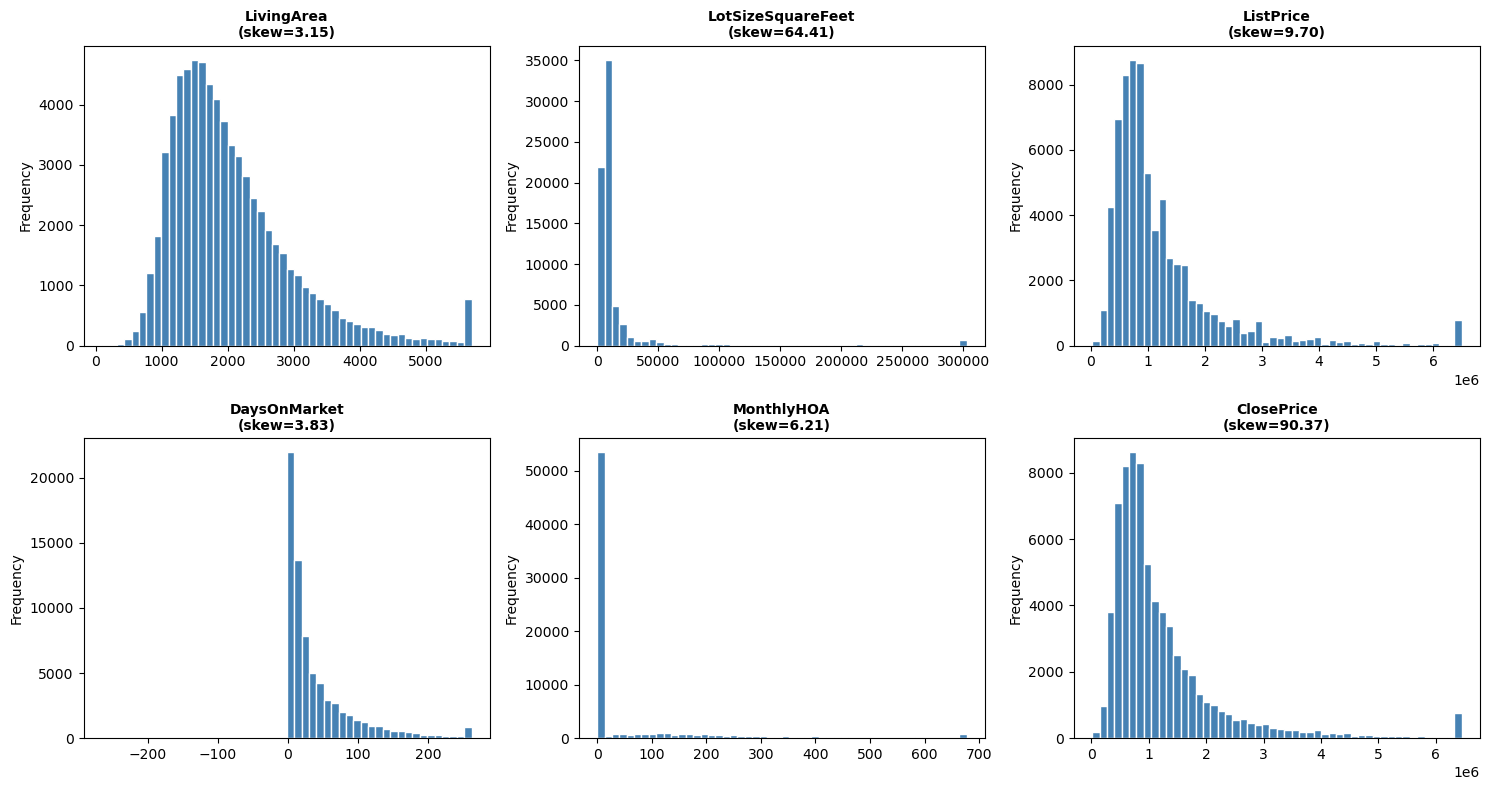

Fields with skew > 1.0 are candidates for log1p transformation before scaling.


In [25]:
# Visual check: are any of these heavily skewed and in need of log-transformation
# BEFORE scaling (scaling alone does not fix skew)?
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
skew_check_cols = ['LivingArea', 'LotSizeSquareFeet', 'ListPrice',
                    'DaysOnMarket', 'MonthlyHOA', 'ClosePrice']

for ax, col in zip(axes.flat, skew_check_cols):
    data = df[col].clip(upper=df[col].quantile(0.99))
    data.plot(kind='hist', bins=50, ax=ax, color='steelblue', edgecolor='white')
    skewness = df[col].skew()
    ax.set_title(f'{col}\n(skew={skewness:.2f})', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('Fields with skew > 1.0 are candidates for log1p transformation before scaling.')

In [26]:
# Apply log1p to heavily right-skewed features (skew > 1.0)
# ClosePrice (target) is log-transformed separately and the model predicts log-price
LOG_TRANSFORM_CANDIDATES = ['LivingArea', 'LotSizeSquareFeet', 'ListPrice', 'MonthlyHOA']

for col in LOG_TRANSFORM_CANDIDATES:
    skewness = df[col].skew()
    if skewness > 1.0:
        df[f'{col}_log'] = np.log1p(df[col])
        print(f'{col}: skew={skewness:.2f} -> log1p transform applied ({col}_log)')
    else:
        print(f'{col}: skew={skewness:.2f} -> no transform needed')

# Target variable log-transform (per Week 2 finding: ClosePrice is heavily right-skewed)
df['ClosePrice_log'] = np.log1p(df['ClosePrice'])
print(f'\nClosePrice: skew={df["ClosePrice"].skew():.2f} -> log1p transform applied (target for linear models)')

LivingArea: skew=3.15 -> log1p transform applied (LivingArea_log)
LotSizeSquareFeet: skew=64.41 -> log1p transform applied (LotSizeSquareFeet_log)
ListPrice: skew=9.70 -> log1p transform applied (ListPrice_log)
MonthlyHOA: skew=6.21 -> log1p transform applied (MonthlyHOA_log)

ClosePrice: skew=90.37 -> log1p transform applied (target for linear models)


---
## 7. Train / Test Split

Per the task specification: **the most recent month is the test set**, and **X preceding
months form the training set**, where X is a tunable window length rather than fixed at 6.

This section builds a reusable function so that X can be experimented with in Week 4+
without re-running the entire preprocessing pipeline.

In [27]:
# Confirm available months in chronological order
available_months = sorted(df['CloseYearMonth'].unique())
print('Available months (chronological):')
for m in available_months:
    print(f'  {m}  ({(df["CloseYearMonth"]==m).sum():,} rows)')

TEST_MONTH = available_months[-1]   # May 2026
print(f'\nTest month (most recent): {TEST_MONTH}')

Available months (chronological):
  2025-11  (9,734 rows)
  2025-12  (10,447 rows)
  2026-01  (7,472 rows)
  2026-02  (8,546 rows)
  2026-03  (11,174 rows)
  2026-04  (12,020 rows)
  2026-05  (12,015 rows)

Test month (most recent): 2026-05


In [28]:
def build_train_test_split(df, test_month, window_x, date_col='CloseYearMonth'):
    '''
    Build a train/test split where:
      - test set  = the single most recent month (test_month)
      - train set = the X months immediately preceding test_month

    window_x is intentionally a parameter, not hardcoded, so that different
    training window lengths can be experimented with in Week 4+ to find the
    value of X that yields the best validation performance.
    '''
    available = sorted(df[date_col].unique())
    test_idx = available.index(test_month)

    if test_idx - window_x < 0:
        raise ValueError(
            f'Requested window_x={window_x} months, but only {test_idx} months '
            f'are available before {test_month}.'
        )

    train_months = available[test_idx - window_x: test_idx]

    train_df = df[df[date_col].isin(train_months)].copy()
    test_df  = df[df[date_col] == test_month].copy()

    return train_df, test_df, train_months

In [29]:
# Example: build the split with the MAXIMUM available window (X=6) as a starting point.
# The optimal X will be determined experimentally in Week 4 by comparing model
# performance across several window lengths (e.g. X=2, 3, 4, 5, 6).
X_WINDOW = 6

train_df, test_df, train_months = build_train_test_split(df, TEST_MONTH, X_WINDOW)

print(f'Training window (X={X_WINDOW} months): {train_months}')
print(f'Training set size: {len(train_df):,} rows')
print(f'Test set size    : {len(test_df):,} rows (month = {TEST_MONTH})')

Training window (X=6 months): [Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
Training set size: 59,393 rows
Test set size    : 12,015 rows (month = 2026-05)


In [30]:
# ── Sanity check across several candidate window lengths ─────────
# This does not select the final X (that happens with actual model evaluation
# in Week 4) -- it simply confirms every candidate window is valid and shows
# how training set size changes with X.
print('Training set size for each candidate window length X:')
for x in range(1, 7):
    try:
        _train, _test, _months = build_train_test_split(df, TEST_MONTH, x)
        print(f'  X={x}: {len(_train):>6,} training rows  |  months = {_months}')
    except ValueError as e:
        print(f'  X={x}: {e}')

Training set size for each candidate window length X:
  X=1: 12,020 training rows  |  months = [Period('2026-04', 'M')]
  X=2: 23,194 training rows  |  months = [Period('2026-03', 'M'), Period('2026-04', 'M')]
  X=3: 31,740 training rows  |  months = [Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
  X=4: 39,212 training rows  |  months = [Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
  X=5: 49,659 training rows  |  months = [Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
  X=6: 59,393 training rows  |  months = [Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]


---
## 8. Finalize Target Encoding & Scaling (Train-Fit, Test-Applied)

With the split defined, target encoding and feature scaling are now fit exclusively on
`train_df` and applied to both `train_df` and `test_df`. This prevents any information
from the test month leaking into the encodings or scale parameters.

In [31]:
# ── Target encode high-cardinality categorical fields ─────────────
TARGET_ENCODE_COLS = ['PostalCode', 'City', 'CountyOrParish', 'HighSchoolDistrict']

encoding_maps = {}
for col in TARGET_ENCODE_COLS:
    enc_map, global_mean = fit_target_encoding(train_df, col, target='ClosePrice')
    encoding_maps[col] = (enc_map, global_mean)

    train_df[f'{col}_encoded'] = apply_target_encoding(train_df, col, enc_map, global_mean)
    test_df[f'{col}_encoded']  = apply_target_encoding(test_df, col, enc_map, global_mean)

    print(f'{col}: target-encoded ({train_df[col].nunique()} unique categories in train)')

PostalCode: target-encoded (1584 unique categories in train)
City: target-encoded (893 unique categories in train)
CountyOrParish: target-encoded (60 unique categories in train)
HighSchoolDistrict: target-encoded (397 unique categories in train)


In [32]:
# ── Fit StandardScaler on train only, apply to both ───────────────
scaler = StandardScaler()
scaler.fit(train_df[NUMERIC_FEATURES_TO_SCALE])

scaled_train = pd.DataFrame(
    scaler.transform(train_df[NUMERIC_FEATURES_TO_SCALE]),
    columns=[f'{c}_scaled' for c in NUMERIC_FEATURES_TO_SCALE],
    index=train_df.index
)
scaled_test = pd.DataFrame(
    scaler.transform(test_df[NUMERIC_FEATURES_TO_SCALE]),
    columns=[f'{c}_scaled' for c in NUMERIC_FEATURES_TO_SCALE],
    index=test_df.index
)

train_df = pd.concat([train_df, scaled_train], axis=1)
test_df  = pd.concat([test_df, scaled_test], axis=1)

print(f'Scaled {len(NUMERIC_FEATURES_TO_SCALE)} numeric features (fit on train, applied to both).')
print()
print('Scaled feature means on train (should be ~0):')
print(scaled_train.mean().round(3))

Scaled 12 numeric features (fit on train, applied to both).

Scaled feature means on train (should be ~0):
LivingArea_scaled               0.0
LotSizeSquareFeet_scaled        0.0
BedroomsTotal_scaled            0.0
BathroomsTotalInteger_scaled   -0.0
Stories_scaled                 -0.0
PropertyAge_scaled              0.0
GarageSpaces_scaled             0.0
ParkingTotal_scaled            -0.0
DaysOnMarket_scaled             0.0
ListPrice_scaled                0.0
BedBathRatio_scaled            -0.0
MonthlyHOA_scaled              -0.0
dtype: float64


In [33]:
# ── One-hot encode CountyOrParish consistently across train/test ─
# Align columns so both sets have the same one-hot structure, even if a
# county is missing from one split (fills with 0 in that case)
county_dummies_train = pd.get_dummies(train_df['CountyOrParish'], prefix='County', drop_first=True)
county_dummies_test  = pd.get_dummies(test_df['CountyOrParish'], prefix='County', drop_first=True)

county_dummies_train, county_dummies_test = county_dummies_train.align(
    county_dummies_test, join='left', axis=1, fill_value=0
)

train_df = pd.concat([train_df, county_dummies_train], axis=1)
test_df  = pd.concat([test_df, county_dummies_test], axis=1)

print(f'One-hot encoded CountyOrParish: {county_dummies_train.shape[1]} columns added.')

One-hot encoded CountyOrParish: 59 columns added.


---
## 9. Final Feature Set Summary

In [34]:
# Confirm no unexpected nulls remain in the model-ready feature set
MODEL_FEATURES_PREVIEW = [
    'ClosePrice', 'ClosePrice_log',
    'LivingArea', 'LivingArea_log', 'LivingArea_scaled',
    'LotSizeSquareFeet', 'LotSizeSquareFeet_scaled',
    'BedroomsTotal', 'BathroomsTotalInteger', 'BedBathRatio',
    'PropertyAge', 'Levels_encoded', 'Stories',
    'GarageSpaces', 'ParkingTotal', 'DaysOnMarket',
    'ListPrice', 'ListPrice_scaled', 'PriceReductionYN',
    'MonthlyHOA', 'PoolPrivateYN', 'ViewYN', 'FireplaceYN',
    'AttachedGarageYN', 'NewConstructionYN',
    'PostalCode_encoded', 'City_encoded', 'CountyOrParish_encoded',
    'HighSchoolDistrict_encoded', 'HighSchoolDistrict_Missing',
    'CloseMonth_sin', 'CloseMonth_cos',
    'Latitude', 'Longitude',
]
MODEL_FEATURES_PREVIEW = [c for c in MODEL_FEATURES_PREVIEW if c in train_df.columns]

print('Null check on final model-ready feature preview (train set):')
null_check = train_df[MODEL_FEATURES_PREVIEW].isnull().sum()
null_check = null_check[null_check > 0]
if len(null_check) == 0:
    print('  No nulls remaining -- ready for modelling.')
else:
    display(null_check.to_frame('null_count'))

print(f'\nFinal train shape: {train_df.shape}')
print(f'Final test shape : {test_df.shape}')

Null check on final model-ready feature preview (train set):


,null_count
BathroomsTotalInteger,1
Latitude,7
Longitude,7



Final train shape: (59393, 163)
Final test shape : (12015, 163)


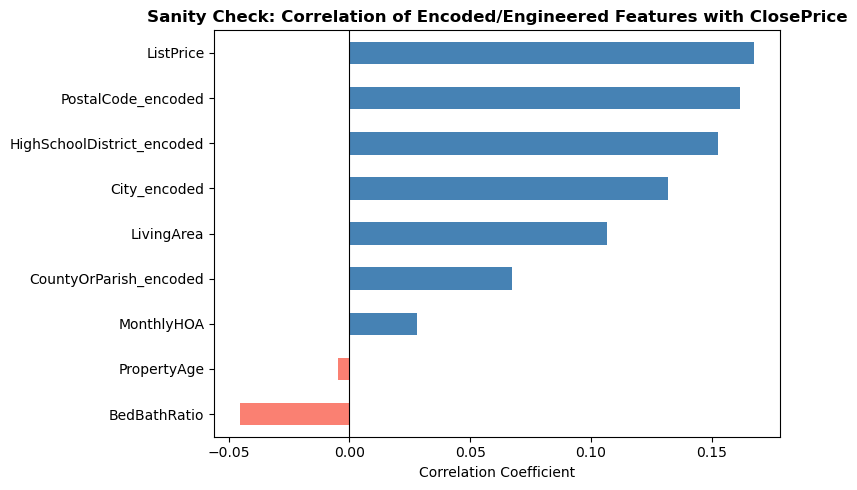

In [35]:
# Quick correlation sanity check: engineered/encoded features vs ClosePrice
sanity_features = [
    'LivingArea', 'BedBathRatio', 'PropertyAge', 'ListPrice',
    'PostalCode_encoded', 'City_encoded', 'CountyOrParish_encoded',
    'HighSchoolDistrict_encoded', 'MonthlyHOA',
]
sanity_features = [c for c in sanity_features if c in train_df.columns]

corr_check = train_df[sanity_features + ['ClosePrice']].corr()['ClosePrice'].drop('ClosePrice')
corr_check = corr_check.sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr_check.plot(kind='barh', ax=ax, color=corr_check.map(lambda x: 'steelblue' if x > 0 else 'salmon'))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Sanity Check: Correlation of Encoded/Engineered Features with ClosePrice', fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

---
## 10. Save Engineered Train / Test Split (For Week 5+ Modelling)

`sfr_cleaned.csv` (raw fields only, no engineered features) was already saved at the
checkpoint in Section 3b -- that is the file the Week 4 baseline model reads from.

The train/test split below **does** include engineered features, encodings, and scaling,
since it is intended for Week 5+ once the baseline has been established. It is saved to
separate files so it never overwrites the raw baseline checkpoint.

---
## 11. Preprocessing Summary

### Fields Dropped (19 total)
100% null: `AboveGradeFinishedArea`, `BelowGradeFinishedArea`, `BuildingAreaTotal`, `TaxAnnualAmount`,
`CoveredSpaces`, `FireplacesTotal`, `BusinessType`, `ElementarySchoolDistrict`, `MiddleOrJuniorSchoolDistrict`, `TaxYear`

Sparse/redundant: `WaterfrontYN`, `BasementYN`, `ElementarySchool`, `MiddleOrJuniorSchool`, `HighSchool`,
`LotSizeAcres`, `LotSizeArea`, `LotSizeDimensions`, `MainLevelBedrooms`

### Rows Dropped
- `ClosePrice < $10,000` (data entry errors)
- `LivingArea == 0` (structural data error)

### Imputation Summary

| Field | Strategy |
|---|---|
| Boolean amenities (Pool, View, Fireplace, AttachedGarage, NewConstruction) | Impute `False` |
| `GarageSpaces`, `ParkingTotal` | Impute `0` |
| `AssociationFee` / `AssociationFeeFrequency` | Impute `0` / `'None'` (no HOA) |
| `LotSizeSquareFeet` | ZIP median -> county median -> global median |
| `Stories` | Mode |
| `YearBuilt` | Median |
| `Flooring` | `'Unknown'` |
| `Levels` | Mode |
| `HighSchoolDistrict` | **Left null** -- to be filled via Week 6 spatial join |

### ⚠️ Two Deliverable Tiers — Read Carefully

This notebook produces **two distinct tiers** of output, saved at different points in the
pipeline, per project convention that the baseline model uses no engineered features:

| File | Contents | Used By |
|---|---|---|
| **`sfr_cleaned.csv`** (Section 3b checkpoint) | Raw/original Trestle fields only, cleaned and imputed. **Zero engineered columns.** | **Week 4 baseline model** |
| `sfr_train.csv` / `sfr_test.csv` (Section 10) | Same cleaned data, PLUS engineered features, encodings, and scaling from Sections 4-9 | Week 5+ modelling, once baseline is established |

**`sfr_cleaned.csv` does NOT contain:** `PropertyAge`, `BedBathRatio`, `SaleToListRatio`,
`PriceReductionYN`, `MonthlyHOA`, `PricePerSqFt`, `Levels_primary`/`Levels_encoded`,
`Flooring_*` binary flags, `CloseMonth_sin`/`CloseMonth_cos`, log-transforms, target/one-hot
encodings, or scaled columns. It also does NOT include `ListPrice` or `OriginalListPrice`
as intended *model inputs* -- they remain in the file for reference but must be excluded
from the baseline model's feature set (see project note on target leakage).

### Encoding & Scaling Strategy (Sections 4-9 -- Week 5+ only)
- **Ordinal:** `Levels_primary` -> `Levels_encoded`
- **One-hot:** `CountyOrParish` (60 categories)
- **Target (mean) encoding, train-fit only:** `PostalCode`, `City`, `HighSchoolDistrict`
- **Scaling:** `StandardScaler` fit on training data only, applied to both train/test

### Train / Test Split
- **Test set:** most recent month (May 2026)
- **Training set:** X months immediately preceding, where X is tunable (`build_train_test_split`
  function supports X = 1 through 6)
- **Next step (Week 4):** experimentally evaluate model performance across X = 2, 3, 4, 5, 6 to
  select the optimal training window length, using the raw-field baseline model

### Leakage Precautions
- Target encoding and feature scaling are fit **exclusively on the training set** (Week 5+ files)
- `ListPrice` / `OriginalListPrice` must be excluded from actual model features at every stage
  (off-market properties don't have a ListPrice, and both cause target leakage)
- `SaleToListRatio` and `PricePerSqFt` use `ClosePrice` directly -- diagnostic only, never
  a model input

### Deliverables
- `notebooks/02_preprocessing.ipynb` (this notebook)
- `data/cleaned/sfr_cleaned.csv` -- **raw/cleaned fields only, zero engineered features (Week 4 baseline input)**
- `data/cleaned/sfr_train.csv` -- engineered + encoded + scaled training split (Week 5+)
- `data/cleaned/sfr_test.csv` -- engineered + encoded + scaled test split (Week 5+)